# Animated Line Chart
This notebook demonstrates how to create an animated custom visualization using
`seaborn` and `matplotlib`.

## Imports and Configuration

In [61]:
import os
from pathlib import Path
from multiprocessing import Pool

import pandas as pd
import time
from tqdm import tqdm as tqdm
import numpy as np
import math

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.patches as patches
import matplotlib.transforms as transforms
import seaborn as sns
import matplotlib.dates as mdates
import humanize

In [62]:
font_path = '/usr/share/fonts/noto_sans_mono/NotoSansMono_SemiCondensed-SemiBold.ttf'
font_prop = fm.FontProperties(fname=font_path)

rich_black = '#0D1B2A'
satin_sheen_gold = '#C59849'
chestnut = '#A53F2B'
ash_gray = '#96BBBB'

In [63]:
background_color = rich_black

text_color = '#fefae0'
dpi = 100

sns.set_theme(
    style='darkgrid',
    context='notebook',
    font=font_prop.get_name(),
    rc={
        'font.weight': 'semibold',
        'axes.labelweight': 'semibold',
        'axes.titlesize': 'xx-large',
        'axes.titleweight': 'semibold',
        'axes.labelsize': 'x-large',
        'figure.facecolor': background_color,
        'axes.facecolor': background_color,
        'text.color': text_color,
        'axes.labelcolor': text_color,
        'xtick.color': text_color,
        'ytick.color': text_color,
        'axes.edgecolor': text_color,
        'figure.dpi': dpi,
        'font.size': 10,
        'grid.color': '#1b2631',
        'axes.spines.top': False,
        'axes.spines.right': False,
        'axes.spines.left': False,
        'axes.spines.bottom': False,
    },
)

## Plotter Function

In [64]:
# This function will generate frames for the animation
def create_frames(lower_bound, upper_bound, frames_folder_path):
    """
    Plotter function to generate frames for the animation.
    """

    for frame in range(lower_bound, upper_bound):
        pct = frame/nframes_total
        # Explicitly keeping half the frames at 100% to have time to change the
        # google slide before the gif starts playing again from the beginning
        pct = min(1, pct * 2)

        fig, ax = plot_frame(pct=pct)

        fig.savefig(
            frames_folder_path / f"frame_{frame:05d}.png",
            dpi=dpi
            )

        plt.close(fig)

In [65]:
def frame_to_upper_bound(current_frame, nframes_total, data_rows):
    """
    Calculate the upper bound for the frame based on the total number of frames.
    """

    return math.ceil(current_frame / nframes_total * data_rows)

## Data Loading

In [66]:
# Create a dataframe with dummy data for chewing gums bougt from 2012 to 2024,
# with an increasing trend for the last 2 years
df = pd.DataFrame({
    'date': pd.date_range(start='2012-01-01', end='2024-12-31', freq='D')
    })

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['year_month'] = df['date'].dt.to_period('M')
df['chewing_gums'] = np.random.poisson(lam=20, size=len(df))
df.loc[df['year'] >= 2022, 'chewing_gums'] += np.random.poisson(lam=10, size=len(df.loc[df['year'] >= 2022]))
df['chewing_gums'] = df['chewing_gums'].astype(int)
df.sort_values(by=['date'], inplace=True)
df.reset_index(drop=True, inplace=True)
df.head(3)

,date,year,month,day,year_month,chewing_gums
0,2012-01-01,2012,1,1,2012-01,18
1,2012-01-02,2012,1,2,2012-01,19
2,2012-01-03,2012,1,3,2012-01,21


In [67]:
df

,date,year,month,day,year_month,chewing_gums
0,2012-01-01,2012,1,1,2012-01,18
1,2012-01-02,2012,1,2,2012-01,19
2,2012-01-03,2012,1,3,2012-01,21
3,2012-01-04,2012,1,4,2012-01,20
4,2012-01-05,2012,1,5,2012-01,19
...,...,...,...,...,...,...
4744,2024-12-27,2024,12,27,2024-12,23
4745,2024-12-28,2024,12,28,2024-12,22
4746,2024-12-29,2024,12,29,2024-12,24
4747,2024-12-30,2024,12,30,2024-12,31


In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4749 entries, 0 to 4748
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          4749 non-null   datetime64[ns]
 1   year          4749 non-null   int32         
 2   month         4749 non-null   int32         
 3   day           4749 non-null   int32         
 4   year_month    4749 non-null   period[M]     
 5   chewing_gums  4749 non-null   int64         
dtypes: datetime64[ns](1), int32(3), int64(1), period[M](1)
memory usage: 167.1 KB


In [69]:
df.isna().sum()

date            0
year            0
month           0
day             0
year_month      0
chewing_gums    0
dtype: int64

In [70]:
viz_df = df.groupby([
    # 'year_month'
    'year'
    ]).agg({
    'chewing_gums': 'sum'
    }).reset_index()

viz_df

,year,chewing_gums
0,2012,7311
1,2013,7304
2,2014,7395
3,2015,7206
4,2016,7409
5,2017,7248
6,2018,7162
7,2019,7376
8,2020,7229
9,2021,7304


This is the plot we are starting from, with the sales binned by year.

In [71]:
def base_fig_ax():
    return plt.subplots(
            figsize=(14, 8),
            dpi=dpi
            )

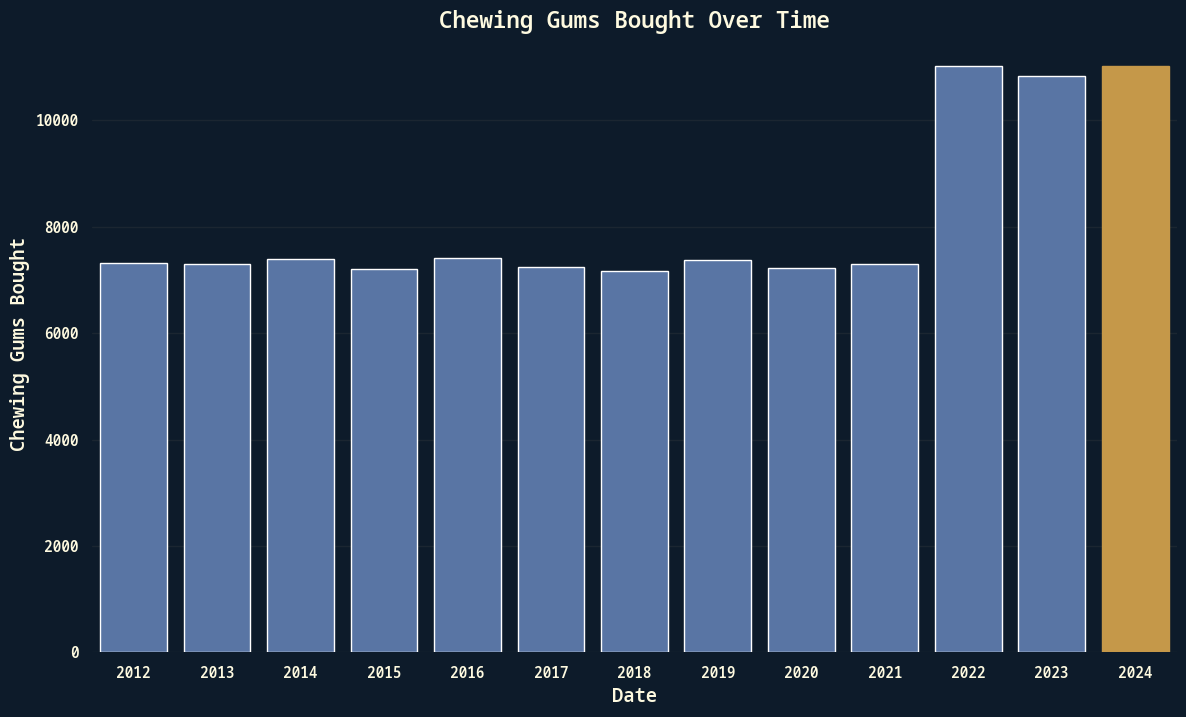

In [72]:
# plot the chewing gums bought over time, with binning using a bar chart
fig, ax = base_fig_ax()

bar_plot = sns.barplot(
    data=viz_df,
    x='year',
    y='chewing_gums',
    ax=ax,
    )

# color the last bar in satin_sheen_gold
last_bar = bar_plot.patches[-1]
last_bar.set_color(satin_sheen_gold)

# Get all properties of the last bar
last_bar_x = last_bar.get_x()
last_bar_y = last_bar.get_y()
last_bar_width = last_bar.get_width()
last_bar_height = last_bar.get_height()
last_bar_color = last_bar.get_facecolor()
last_bar_width_pct = last_bar_width / (ax.get_xlim()[1] - ax.get_xlim()[0])

# Calculate the center of the bar for rotation
last_bar_center_x = last_bar_x + last_bar_width/2
last_bar_center_y = last_bar_y + last_bar_height/2

# To be used with the animation
upper_limit = ax.get_xlim()[1] - 1
lower_limit = ax.get_xlim()[0]
total_xaxis_distance = upper_limit - lower_limit

plt.title('Chewing Gums Bought Over Time')
plt.xlabel('Date')
plt.ylabel('Chewing Gums Bought')
plt.show()

This is the plot we get to with only the last bar

In [73]:
def get_bar_center_x(bar):
    return bar.get_x() + bar.get_width()/2

def reshape_bar(bar,
                ax,
                last_bar_center_x=last_bar_center_x,
                last_bar_width_pct=last_bar_width_pct
                ):
    bar_center_x = get_bar_center_x(bar)
    bar.set_width(last_bar_width_pct * (ax.get_xlim()[1] - ax.get_xlim()[0]))
    current_width = bar.get_width()
    bar.set_x(bar_center_x - current_width/2)

In [74]:
def plot_frame(pct):
    # plot the chewing gums bought over time, with binning using a bar chart
    fig, ax = base_fig_ax()

    bar_plot = sns.barplot(
        data=viz_df,
        x='year',
        y='chewing_gums',
        ax=ax,
        )

    new_upper_limit = ax.get_xlim()[0] + total_xaxis_distance * pct

    ax.set_xlim(
            new_upper_limit,
            ax.get_xlim()[1]
            )

    # color the last bar in satin_sheen_gold
    current_last_bar = bar_plot.patches[-1]
    current_last_bar.set_color(satin_sheen_gold)
    reshape_bar(current_last_bar, ax)

    for bar in bar_plot.patches[:-1]:
        reshape_bar(bar, ax)
        bar.set_alpha(1 - pct)

    plt.title('Chewing Gums Bought Over Time')
    plt.xlabel('Date')
    plt.ylabel('Chewing Gums Bought')

    return fig, ax

In [75]:
FRAMES = 500
frames_folder_name = "bar_chart"
nframes_total = FRAMES

In [76]:
base_frames_folder_path = Path('frames')
frames_folder_path = base_frames_folder_path / Path(frames_folder_name)

animations_folder_path = Path('animations')

print(f"Frames folder path:      {frames_folder_path}")
print(f"Animations folder path:  {animations_folder_path}")

Frames folder path:      frames/bar_chart
Animations folder path:  animations


In [77]:
NPLOTTERS = os.cpu_count()

In [78]:
bounds = np.linspace(0, nframes_total, NPLOTTERS+1, dtype=int)
bounds

array([  0,  41,  83, 125, 166, 208, 250, 291, 333, 375, 416, 458, 500])

In [79]:
iterable_arguments_for_plotter = [
        (bounds[i], bounds[i+1], frames_folder_path)
        for i in range(NPLOTTERS)
        ]

In [80]:
if not frames_folder_path.exists():
    frames_folder_path.mkdir(parents=True, exist_ok=True)

# Clear frames_folder
for file in frames_folder_path.glob("*.png"):
    file.unlink()

# Create the animations folder if it does not exist
if not animations_folder_path.exists():
    animations_folder_path.mkdir(parents=True, exist_ok=True)

In [81]:
with Pool(processes=NPLOTTERS) as p:
    time.sleep(1)

    timer0 = time.perf_counter()

    p.starmap(create_frames, iterable_arguments_for_plotter, chunksize=1)

    timer1 = time.perf_counter()

    deltat = timer1-timer0

    print(f"\nGenerated {nframes_total} frames in {humanize.naturaldelta(deltat)} ({deltat:.1f} seconds, {nframes_total/deltat:.1f} FPS)")


Generated 500 frames in 13 seconds (13.3 seconds, 37.5 FPS)


## Video Generation

Now you can use the generated frames to create an animated GIF or video using
tools like `ffmpeg`.
<br />
<br />
See executable `./gen_animation.sh` for an example of how to generate a video.
The executable takes an argument, the folder name where the frames are
stored, and generates a video named `<folder_name>.mp4`.
<br />
<br />
The following cell runs the shell command to generate the video with the
default gen_animation.sh script.

In [82]:
# %%time
# Run the shell command
# !./gen_animation.sh {frames_folder_path} && echo "\nVideo generated successfully.\n"

And this one generates a gif:

In [129]:
%%time
# Run the shell command
!./gen_gif.sh {frames_folder_path} && echo "\nGIF generated successfully.\n"

ffmpeg version 5.1.6-0+deb12u1 Copyright (c) 2000-2024 the FFmpeg developers
  built with gcc 12 (Debian 12.2.0-14)
  configuration: --prefix=/usr --extra-version=0+deb12u1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libglslang --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librist --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libsvtav1 --enable-libtheora --enable-libtwolame --enable-libvidstab --enab

In [91]:
slide_snapshots_folder_path = Path('slide_snapshots')

if not slide_snapshots_folder_path.exists():
    slide_snapshots_folder_path.mkdir(parents=True, exist_ok=True)

In [127]:
fig, ax = plot_frame(pct=0)

fig.savefig(
        slide_snapshots_folder_path / "before_animation.png",
        dpi=dpi
        )

plt.close(fig)

In [118]:
fig, ax = plot_frame(pct=1)

fig.savefig(
        slide_snapshots_folder_path / "after_animation.png",
        dpi=dpi
        )

plt.close(fig)

In [119]:
percentages_of_sales = [
        {'name': 'Kiosk', 'pct': 0.4, 'color': chestnut},
        {'name': 'Supermarket', 'pct': 0.35, 'color': ash_gray},
        {'name': 'Vending Machine', 'pct': 0.25, 'color': 'green'},
        ]

In [133]:
fig, ax = plot_frame(pct=1)

# get the last bar
last_bar = ax.patches[-1]

# get the bar properties
current_last_bar_height = last_bar.get_height()

plt.title(f'Chewing Gums Bought Over Time')
plt.xlabel('Date')
plt.ylabel('Chewing Gums Bought')

previous_breakdown_height = 0
text_side = 'left'

for i, sale in enumerate(percentages_of_sales):
    sale_type = sale['name']
    sale_pct = sale['pct']
    sale_color = sale['color']

    # add a rectangle on top of the last bar, with height proportional to the
    # percentage of sales
    rect = patches.Rectangle(
            (last_bar.get_x(), previous_breakdown_height),
            last_bar.get_width(),
            current_last_bar_height * sale_pct,
            linewidth=1,
            edgecolor=sale_color,
            facecolor=sale_color,
            alpha=0.7
            )

    ax.add_patch(rect)

    current_rect_center_y = previous_breakdown_height + (current_last_bar_height * sale_pct)/2

    current_x_axis_distance = ax.get_xlim()[1] - ax.get_xlim()[0]
    text_distance_from_bar = current_x_axis_distance * 0.25

    if text_side == 'left':
        text_x = last_bar.get_x() - text_distance_from_bar
    else:
        text_x = last_bar.get_x() + text_distance_from_bar

    ax.text(
            text_x,
            current_rect_center_y,
            f"{sale_type} {sale_pct*100:.0f}%",
            color=sale_color,
            fontsize=16,
            fontweight='semibold',
            ha='center',
            va='center',
            )

    # # draw a line from the rectangle to the text
    # ax.plot(
    #         [last_bar.get_x() + last_bar.get_width()/2, text_x],
    #         [current_rect_center_y, current_rect_center_y],
    #         color=sale_color,
    #         linewidth=1,
    #         linestyle='--',
    #         alpha=0.7
    #         )

    line_y = current_rect_center_y - (current_last_bar_height * 0.04)

    # draw a line from the rectangle to the text
    horizontal_line = ax.plot(
            [last_bar.get_x() + last_bar.get_width()/2, text_x],
            # [current_rect_center_y, current_rect_center_y],
            [line_y, line_y],
            color=sale_color,
            linewidth=2,
            linestyle='--',
            alpha=0.7
            )

    # draw a line from the end of the previous line to the text
    vertical_line = ax.plot(
            [text_x, text_x],
            [line_y, line_y + (current_last_bar_height * 0.02)],
            color=sale_color,
            linewidth=2,
            linestyle='--',
            alpha=0.7
            )

    previous_breakdown_height += current_last_bar_height * sale_pct

    if text_side == 'left':
        text_side = 'right'
    else:
        text_side = 'left'

    fig.savefig(
            slide_snapshots_folder_path / f"with_sales_{i+1}.png",
            dpi=dpi
            )

    plt.close(fig)